# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("loan_data.csv")
df.head(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1
5,22,male,Bachelor,70130.700025,6,MORTGAGE,9008.104188,VENTURE,12.575501,0.128447,22,770.974257,No,0
6,41,female,Associate,86965.993882,11,OWN,23398.537788,EDUCATION,11.770607,0.269054,19,596.305523,No,1
7,72,female,Associate,60412.931964,6,MORTGAGE,24495.392501,PERSONAL,9.146556,0.405466,19,734.020668,No,0
8,21,male,Bachelor,77241.160427,25,RENT,17674.382881,DEBTCONSOLIDATION,14.211276,0.228821,22,653.042056,No,0
9,49,male,Doctorate,57373.429325,4,OWN,14848.496412,PERSONAL,12.188035,0.258804,26,738.978230,No,1


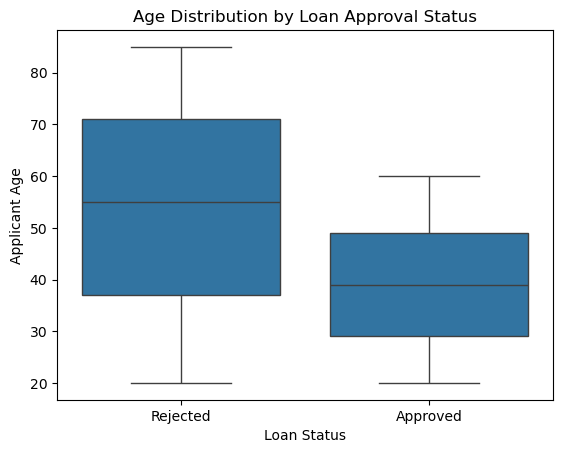

In [11]:
sns.boxplot(x="loan_status", y="person_age", data=df)

plt.title("Age Distribution by Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Applicant Age")

plt.xticks([0,1], ["Rejected", "Approved"])

plt.show()

### Age vs Loan Approval

This plot compares the ages of applicants whose loans were **rejected** and those whose loans were **approved**.

From the chart, we can see that people in the **approved group tend to be younger**, while people in the **rejected group tend to be older**.

This suggests that **age might be related to the loan decision**, since younger applicants appear to receive approvals more often than older applicants.

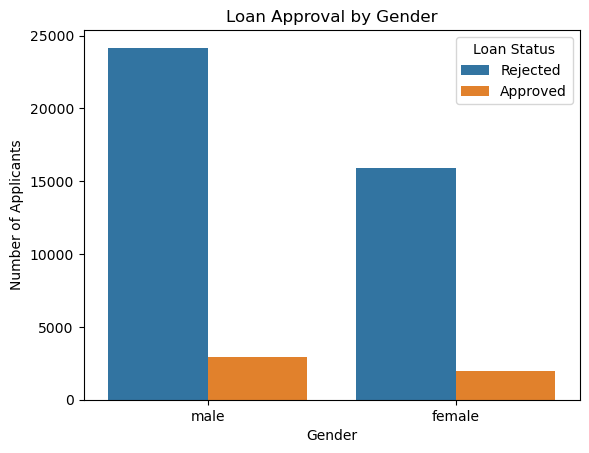

In [12]:
sns.countplot(x="person_gender", hue="loan_status", data=df)

plt.title("Loan Approval by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Applicants")
plt.legend(title="Loan Status", labels=["Rejected", "Approved"])

plt.show()

### Loan Approval by Gender

This chart shows the number of loan applications that were **approved** and **rejected** for each gender.

From the chart, we can see that both **male and female applicants have more rejections than approvals**. The number of male applicants is higher than female applicants overall, which is why the bars for males are taller.

When comparing the approval and rejection patterns, the difference between males and females does not appear very large. This suggests that **gender may not strongly influence the loan approval decision**.

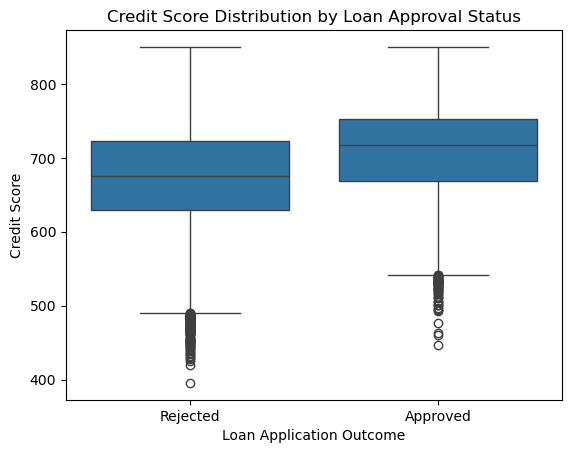

In [15]:

sns.boxplot(x="loan_status", y="credit_score", data=df)

plt.title("Credit Score Distribution by Loan Approval Status")
plt.xlabel("Loan Application Outcome")
plt.ylabel("Credit Score")

plt.xticks([0,1], ["Rejected", "Approved"])

plt.show()

### Credit Score vs Loan Approval
This plot compares the credit scores of applicants whose loans were **rejected** versus **approved**. Approved applicants tend to have **higher credit scores** (median ~720) compared to rejected applicants (median ~670). This suggests that **credit score is a strong driver** of the loan decision.

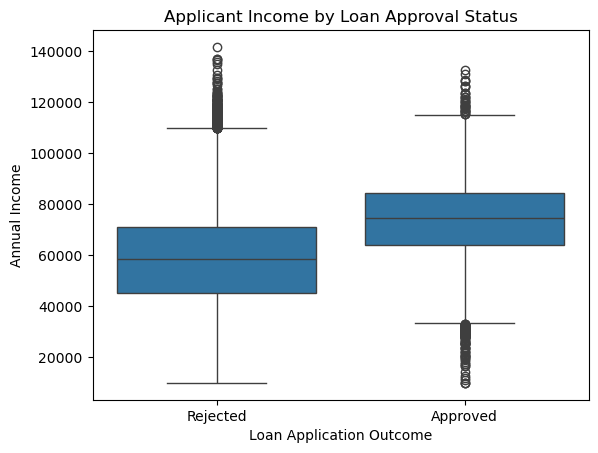

In [16]:
sns.boxplot(x="loan_status", y="person_income", data=df)

plt.title("Applicant Income by Loan Approval Status")
plt.xlabel("Loan Application Outcome")
plt.ylabel("Annual Income")

plt.xticks([0,1], ["Rejected", "Approved"])

plt.show()

### Applicant Income vs Loan Approval
This plot compares the annual incomes of **rejected** versus **approved** applicants. Approved applicants tend to earn **more income** compared to rejected applicants. This suggests that **income is related to loan approval**, with higher earners more likely to be approved.

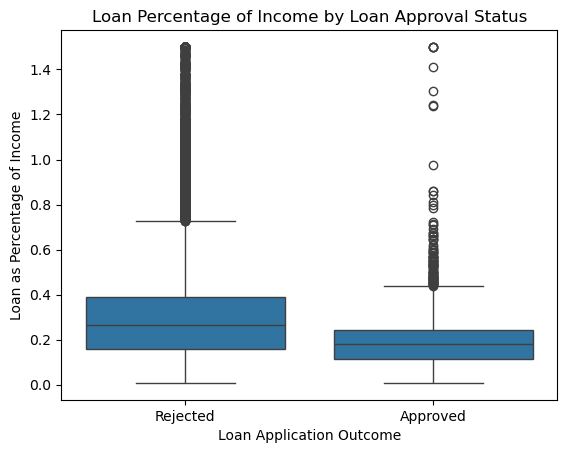

In [17]:
sns.boxplot(x="loan_status", y="loan_percent_income", data=df)

plt.title("Loan Percentage of Income by Loan Approval Status")
plt.xlabel("Loan Application Outcome")
plt.ylabel("Loan as Percentage of Income")

plt.xticks([0,1], ["Rejected", "Approved"])

plt.show()

### Loan Percentage of Income vs Loan Approval
This plot compares the loan-to-income ratio for **rejected** versus **approved** applicants. Rejected applicants tend to have a **higher ratio** (median ~0.27) while approved applicants have a **lower ratio** (median ~0.18). This suggests that **borrowing a smaller share of income** improves approval chances.

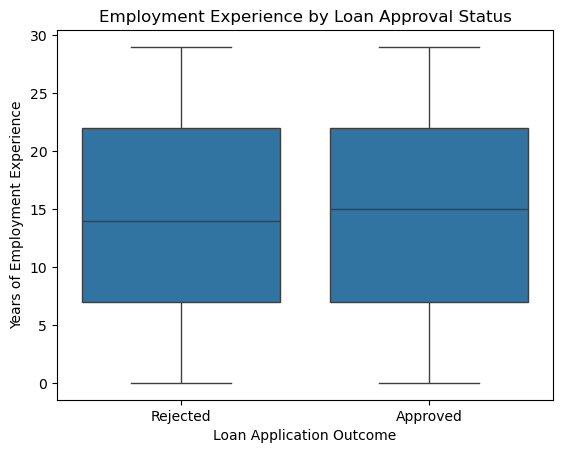

In [19]:
sns.boxplot(x="loan_status", y="person_emp_exp", data=df)

plt.title("Employment Experience by Loan Approval Status")
plt.xlabel("Loan Application Outcome")
plt.ylabel("Years of Employment Experience")

plt.xticks([0,1], ["Rejected", "Approved"])

plt.show()

### Employment Experience vs Loan Approval
This plot compares years of employment experience for **rejected** versus **approved** applicants. Both groups show **nearly identical distributions**, with medians around 14–15 years. This suggests that **employment experience has little influence** on the loan decision.

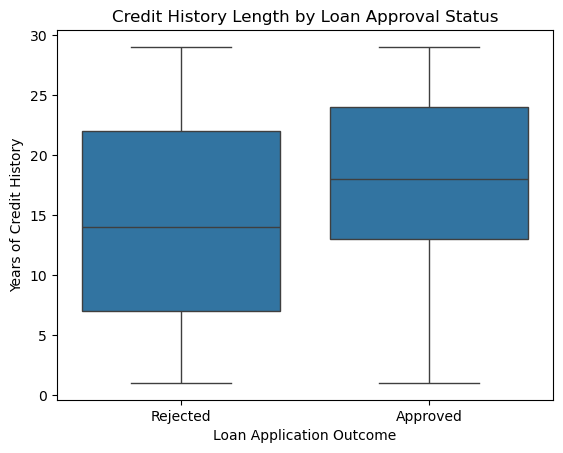

In [20]:
sns.boxplot(x="loan_status", y="cb_person_cred_hist_length", data=df)

plt.title("Credit History Length by Loan Approval Status")
plt.xlabel("Loan Application Outcome")
plt.ylabel("Years of Credit History")

plt.xticks([0,1], ["Rejected", "Approved"])

plt.show()

### Credit History Length vs Loan Approval
This plot compares credit history length for **rejected** versus **approved** applicants. Approved applicants tend to have a **slightly longer credit history** (median ~18 years) versus rejected applicants (median ~14 years). This suggests that **credit history length has a modest relationship** with loan approval.

## Overall Conclusion
Looking at all the charts, the model mostly makes decisions based on **credit score, income, and how much of their income the loan takes up**. These all make sense as reasons to approve or deny a loan. Employment experience and credit history length do not seem to matter much. Gender also does not appear to be a major factor since both men and women are rejected at similar rates. However, **age is a big problem** — younger people are getting approved much more often than older people, and that gap is very large. Since it is **illegal to discriminate based on age**, the bank could face **serious legal trouble** if the model is found to be treating older applicants unfairly. This should be investigated right away.